## Exploración inicial Conecta

### 1. Carga y estructura del Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import unicodedata

pd.set_option("display.float_format", lambda x: f"{x:.2f}")

df = pd.read_csv('conecta_sa_grupo1.csv')
df.head()

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


In [3]:
print("Tamaño:", df.shape)
print("\nTipos de datos:\n", df.dtypes)

df.info()

Tamaño: (453803, 20)

Tipos de datos:
 user_id                  object
mes                      object
pais                     object
region                   object
ciudad                   object
localidad                object
tier_localidad           object
latitud                 float64
longitud                float64
plan_type                object
signup_date              object
tenure_months             int64
es_cliente_nuevo_mes       bool
monthly_revenue_cop     float64
data_usage_gb           float64
complaints_month          int64
nps_score               float64
churned                   int64
churn_type               object
churn_date               object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453803 entries, 0 to 453802
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               453803 non-null  object 
 1   mes                   453803 non-nu

In [4]:
display(df.head())
display(df.tail())

,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
0,CNX-213573,2026-04,Colombia,Caribe,Montería,El Prado,Media,8.71,-75.92,Pospago,2023-08-15,31,False,97400.00,26.30,1,28.80,0,NaN,NaN
1,CNX-157268,2026-04,Colombia,Andina,Bogotá,Zona Norte,Baja,4.67,-74.04,Pospago,2024-04-26,23,False,77200.00,10.60,3,NaN,0,NaN,NaN
2,CNX-202890,2026-04,Colombia,Caribe,Cartagena,Manga,Media,10.43,-75.45,Pospago,2018-02-15,97,False,59600.00,2.90,8,25.20,0,NaN,NaN
3,CNX-118729,2026-04,Colombia,Andina,Medellín,Nueva Colombia,Media,6.29,-75.54,Prepago,2021-04-29,59,False,27700.00,6.90,0,NaN,0,NaN,NaN
4,CNX-162746,2026-04,Colombia,Andina,Bucaramanga,Cabecera,Alta,7.06,-73.15,Pospago,2024-04-17,23,False,24700.00,7.20,1,27.60,1,Competencia,2026-04-18


,user_id,mes,pais,region,ciudad,localidad,tier_localidad,latitud,longitud,plan_type,signup_date,tenure_months,es_cliente_nuevo_mes,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned,churn_type,churn_date
453798,CNX-138968,2026-04,Colombia,Andina,Bogotá,El Poblado,Alta,4.73,-74.05,Prepago,2024-11-10,16,False,31900.00,8.00,1,NaN,0,NaN,NaN
453799,CNX-120055,2026-03,Colombia,Andina,Medellín,Nueva Colombia,Media,6.28,-75.54,Pospago,2023-11-04,27,False,65900.00,8.20,1,NaN,0,NaN,NaN
453800,CNX-192497,2026-03,Colombia,Caribe,Barranquilla,Suba,Media,10.97,-74.76,Convergente,2024-03-29,23,False,98300.00,1.70,6,NaN,0,NaN,NaN
453801,CNX-171760,2026-03,Colombia,Andina,Bucaramanga,Zona Norte,Baja,7.14,-73.16,Convergente,2025-12-16,2,False,113400.00,10.80,1,NaN,0,NaN,NaN
453802,CNX-242358,2026-05,Colombia,Orinoquía,Villavicencio,La Floresta,Media,4.14,-73.62,Pospago,2025-11-18,5,False,83400.00,11.30,1,NaN,0,NaN,NaN


### 2. Calidad de datos

Duplicados Exactos

In [5]:
duplicados = df.duplicated().sum()
print(f"Cantidad de duplicados exactos: {duplicados}") 
print(f"Porcentaje de duplicados: {duplicados / len(df) * 100:.2f}%")

Cantidad de duplicados exactos: 1355
Porcentaje de duplicados: 0.30%


Variantes por región

In [6]:
df["region"].value_counts().sort_index()

region
Amazonia         125
Amazonía        8195
Andina        269562
Andina          4052
Caribe         78041
Caribe          1228
Orinoquia        317
Orinoquía      20082
Pacifica        1081
Pacífica       71120
Name: count, dtype: int64

In [7]:
df["plan_type"].value_counts().sort_index()

plan_type
CONVERGENTE      2315
Convergente    110836
POSPAGO          3160
PREPAGO          3596
Pospago        156014
Prepago        177882
Name: count, dtype: int64

Latitud y longitud

In [8]:
fuera_colombia = (
    (df["latitud"] < -4.3) |
    (df["latitud"] > 13.5) |
    (df["longitud"] < -79.1) |
    (df["longitud"] > -66.8)
)
 
print(
    "Registros con coordenadas fuera del rango aproximado de Colombia:",
    fuera_colombia.sum()
)
df.loc[
    fuera_colombia,
    ["user_id", "pais", "region", "ciudad", "latitud", "longitud"]
].head(20)
 

df.loc[
    fuera_colombia,
    ["user_id", "pais", "region", "ciudad", "latitud", "longitud"]
].head(20)

Registros con coordenadas fuera del rango aproximado de Colombia: 4537


,user_id,pais,region,ciudad,latitud,longitud
33,CNX-136091,Colombia,Andina,Bogotá,-74.05,4.73
120,CNX-165603,Colombia,Andina,Bucaramanga,0.00,0.00
198,CNX-152864,Colombia,Andina,Bogotá,94.59,-193.63
201,CNX-226832,Colombia,Pacífica,Buenaventura,95.95,-197.05
228,CNX-192844,Colombia,Caribe,Barranquilla,0.00,0.00
503,CNX-108729,Colombia,Andina,Medellín,-75.63,6.22
537,CNX-100016,Colombia,Andina,Medellín,0.00,0.00
565,CNX-140328,Colombia,Andina,Bogotá,-74.05,4.73
569,CNX-180889,Colombia,Andina,Manizales,0.00,0.00
886,CNX-247605,Colombia,Amazonía,Florencia,0.00,0.00


Coordenadas

In [9]:
coordenadas_cero = (
    (df["latitud"] == 0) &
    (df["longitud"] == 0)
)
 
print(
    "Registros con coordenadas (0, 0):",
    coordenadas_cero.sum()
)
df.loc[
    coordenadas_cero,
    ["user_id", "pais", "region", "ciudad", "latitud", "longitud"]
].head(20)
 

Registros con coordenadas (0, 0): 1362


,user_id,pais,region,ciudad,latitud,longitud
120,CNX-165603,Colombia,Andina,Bucaramanga,0.00,0.00
228,CNX-192844,Colombia,Caribe,Barranquilla,0.00,0.00
537,CNX-100016,Colombia,Andina,Medellín,0.00,0.00
569,CNX-180889,Colombia,Andina,Manizales,0.00,0.00
886,CNX-247605,Colombia,Amazonía,Florencia,0.00,0.00
944,CNX-107448,Colombia,Andina,Medellín,0.00,0.00
1939,CNX-203173,Colombia,Caribe,Cartagena,0.00,0.00
2618,CNX-250797,Colombia,Andina,Bogotá,0.00,0.00
2658,CNX-132390,Colombia,Andina,Medellín,0.00,0.00
3484,CNX-197835,Colombia,Caribe,Barranquilla,0.00,0.00


Nulos


In [10]:
nulos = pd.DataFrame({
    "Cantidad de nulos": df.isnull().sum(),
    "Porcentaje de nulos": (df.isnull().mean() * 100).round(2)
})
 
nulos = nulos.sort_values(
    "Cantidad de nulos",
    ascending=False
)
 
display(nulos)

,Cantidad de nulos,Porcentaje de nulos
churn_type,440576,97.09
churn_date,440576,97.09
nps_score,365347,80.51
latitud,6805,1.50
longitud,6805,1.50
pais,0,0.00
mes,0,0.00
user_id,0,0.00
region,0,0.00
tier_localidad,0,0.00


### 3. Estadistica Descriptiva

In [11]:
columnas_numericas = df.select_dtypes(include="number").columns
 
df[columnas_numericas].describe()

,latitud,longitud,tenure_months,monthly_revenue_cop,data_usage_gb,complaints_month,nps_score,churned
count,446998.00,446998.00,453803.00,453803.00,453803.00,453803.00,88456.00,453803.00
mean,5.85,-74.60,17.84,64217.18,10.84,1.37,32.95,0.03
std,7.44,8.92,17.65,69055.49,6.43,1.56,22.37,0.17
min,-78.77,-200.00,0.00,3200.00,0.10,0.00,-58.40,0.00
25%,4.67,-75.63,5.00,34300.00,6.10,0.00,18.00,0.00
50%,6.22,-75.53,12.00,52600.00,9.60,1.00,33.70,0.00
75%,7.07,-74.05,25.00,81700.00,14.20,2.00,48.50,0.00
max,98.98,11.30,98.00,6080000.00,60.00,18.00,100.00,1.00


In [12]:
print('Registros totales dataset:',df.shape[0],'\n')
print(f'Describe para nps:',)
print(df['nps_score'].describe(),'\n')
print(f"Porcentaje de nulos en nps_score: {df['nps_score'].isnull().mean() * 100:.3f}%")

Registros totales dataset: 453803 

Describe para nps:
count   88456.00
mean       32.95
std        22.37
min       -58.40
25%        18.00
50%        33.70
75%        48.50
max       100.00
Name: nps_score, dtype: float64 

Porcentaje de nulos en nps_score: 80.508%


In [13]:
df['tiene_nps'] = df['nps_score'].notnull()
print(df[['churned','mes','tiene_nps']].value_counts())

churned  mes      tiene_nps
0        2026-05  False        119979
         2026-04  False        119816
         2026-03  False        118904
         2026-05  True          27424
         2026-03  True          27337
         2026-04  True          27116
1        2026-05  False          2326
                  True           2288
         2026-04  False          2192
                  True           2187
         2026-03  False          2130
                  True           2104
Name: count, dtype: int64


Para el Nps_score encontramos que el 80% de los datos se encuentran nulos.

La mayor parte de estos datos pertenecen a los usuarios que siguen activos (churned = 0)

Para los usuarios que salieron por mes encontramos que para alrededor del 50% cuenta con datos:

In [14]:
print('Usuarios inactivos:\n',df[df['churned'] == 1]['tiene_nps'].value_counts(normalize=True) * 100)
(df[df['churned'] == 1]
    .groupby('mes')['tiene_nps']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack(fill_value=0)
)

Usuarios inactivos:
 tiene_nps
False   50.26
True    49.74
Name: proportion, dtype: float64


tiene_nps,False,True
mes,,
2026-03,50.31,49.69
2026-04,50.06,49.94
2026-05,50.41,49.59


### 4. Visualizaciones

In [15]:
def normalizar_texto(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor).strip().lower()
    valor = ''.join(
        c for c in unicodedata.normalize('NFD', valor)
        if unicodedata.category(c) != 'Mn'
    )
    return valor
df["region"] = df["region"].apply(normalizar_texto)

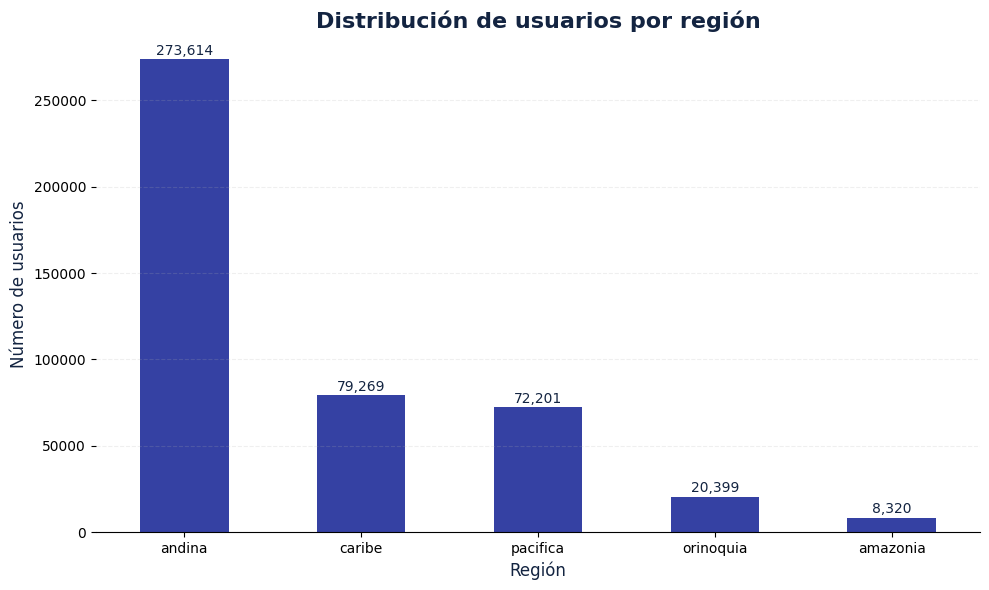

In [ ]:
usuarios_region = (
    df.groupby("region")["user_id"]
      .count()
      .sort_values(ascending=False)
)

ax = usuarios_region.plot(
    kind="bar",
    figsize=(10, 6),
    color="#3541A3",
    edgecolor="none"
)

plt.title(
    "Distribución de usuarios por región",
    fontsize=16,
    fontweight="bold",
    color="#132441"
)

plt.xlabel("Región", fontsize=12, color="#132441")
plt.ylabel("Número de usuarios", fontsize=12, color="#132441")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

for i, valor in enumerate(usuarios_region):
    ax.text(
        i,
        valor + usuarios_region.max() * 0.01,
        f"{valor:,}",
        ha="center",
        fontsize=10,
        color="#132441"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
pie_df = (
    df.groupby("tier_localidad")["user_id"]
      .count()
      .reset_index()
)

fig = px.pie(
    pie_df,
    values="user_id",
    names="tier_localidad",
    title="Distribución de usuarios por tier de localidad",
    color_discrete_sequence=[
        "#3541A3",  
        "#87BBD7",  
        "#DAF561"   
    ],
    hole=0.35
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label",
    marker=dict(
        line=dict(color="white", width=2)
    )
)

fig.update_layout(
    title=dict(
        font=dict(
            size=18,
            color="#132441"
        )
    ),
    legend_title_text="Tier de localidad",
    font=dict(
        size=12,
        color="#132441"
    ),
    paper_bgcolor="white",
    plot_bgcolor="white"
)

fig.show()

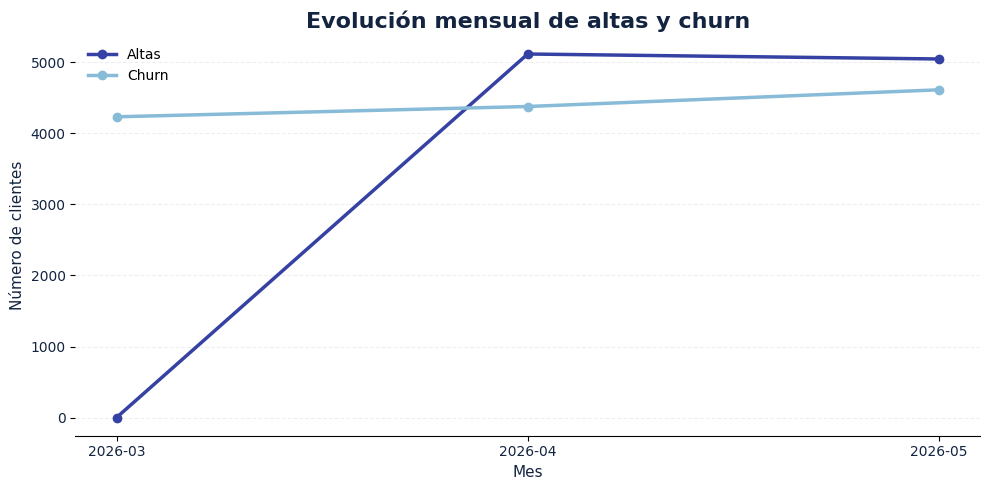

In [ ]:
plt.figure(figsize=(10, 5))

evolucion_clientes = (
    df.groupby("mes")
      .agg(
          altas=("es_cliente_nuevo_mes", "sum"),
          churn=("churned", "sum")
      )
      .reset_index()
)

plt.plot(
    evolucion_clientes["mes"],
    evolucion_clientes["altas"],
    marker="o",
    linewidth=2.5,
    color="#3541A3",
    label="Altas"
)

plt.plot(
    evolucion_clientes["mes"],
    evolucion_clientes["churn"],
    marker="o",
    linewidth=2.5,
    color="#87BBD7",
    label="Churn"
)

plt.title(
    "Evolución mensual de altas y churn",
    fontsize=16,
    fontweight="bold",
    color="#132441"
)

plt.xlabel(
    "Mes",
    fontsize=11,
    color="#132441"
)

plt.ylabel(
    "Número de clientes",
    fontsize=11,
    color="#132441"
)

plt.xticks(color="#132441")
plt.yticks(color="#132441")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

plt.legend(
    frameon=False
)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
df.groupby(["mes", "complaints_month","data_usage_gb"]).count().unstack(fill_value=0)

user_id                                            \
data_usage_gb              0.10  0.20  0.30  0.40  0.50  0.60  0.70  0.80    
mes     complaints_month                                                     
2026-03 0                      1     1     6     6     9    16    19    18   
        1                      0     2     7     5     8    15    21    19   
        2                      0     1     6     7     9    11    14    14   
        3                      1     0     4     5     4     6     7     8   
        4                      0     2     3     1     5     5     6     6   
        5                      0     0     2     1     3     2     4     1   
        6                      0     0     0     0     1     1     2     2   
        7                      0     0     0     1     2     1     0     1   
        8                      0     0     0     1     0     1     0     2   
        9                      0     0     0     1     0     0     1     1   
        10                     0     0     0     0     0     0     0     0   
        11                     0     0     0     0     0     1     0     0   
        12                     0     0     0     0     0     0     0     1   
        13                     0     0     0     0     0     0     0     0   
        14                     0     0     0     0     0     0     0     0   
2026-04 0                      0     0     4    10     9    11    20    24   
        1                      0     0     4     1     6    16    12    27   
        2                      1     0     4     4     5    14    13    13   
        3                      0     0     2     2     2     8    11     9   
        4                      1     2     0     1     3     5     2     5   
        5                      0     0     0     1     1     1     2     2   
        6                      0     1     0     0     3     2     1     0   
        7                      0     1     0     0     1     1     1     1   
        8                      0     0     0     0     2     3     1     1   
        9                      0     0     0     0     0     0     1     4   
        10                     0     0     1     0     0     0     0     0   
        11                     0     0     0     0     1     0     0     1   
        12                     0     0     0     0     0     0     0     0   
        13                     0     0     0     0     0     0     0     0   
        14                     0     0     0     0     0     0     0     0   
        15                     0     0     0     0     0     0     0     0   
        16                     0     0     0     1     0     0     0     0   
2026-05 0                      0     1     2     7     7     7    16    24   
        1                      0     3     3     7    11    21    17    21   
        2                      0     3     5     7    11     6     6    19   
        3                      1     1     2     3     9     8     8     9   
        4                      0     1     1     3     3     3     5     3   
        5                      0     0     0     1     2     1     4     5   
        6                      0     0     0     3     1     0     2     3   
        7                      0     0     0     1     2     1     2     1   
        8                      0     0     0     1     3     2     2     1   
        9                      0     0     0     1     1     1     1     3   
        10                     0     0     0     1     1     0     0     2   
        11                     0     0     0     0     0     0     1     1   
        12                     0     0     0     0     0     0     0     1   
        13                     0     0     0     0     0     0     0     0   
        14                     0     0     0     0     0     0     0     0   
        15                     0     0     0     0     0     0     0     0   
        18                     0     0     0   

In [ ]:
bins = [0, 5, 10, 15, 20, 25, 30, 60]
labels = ["0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30+"]
df["rango_consumo"] = pd.cut(
    df["data_usage_gb"], bins=bins, labels=labels, include_lowest=True
)

resumen_consumo = (
    df.groupby("rango_consumo", observed=True)
      .agg(
          clientes=("user_id", "count"),
          quejas_totales=("complaints_month", "sum"),
          quejas_promedio=("complaints_month", "mean"),
      )
      .round(2)
)

print("Correlacion data_usage_gb vs complaints_month:",
      round(df["data_usage_gb"].corr(df["complaints_month"]), 4))
resumen_consumo

Correlacion data_usage_gb vs complaints_month: -0.2007


,clientes,quejas_totales,quejas_promedio
rango_consumo,,,
0-5,79012,149203,1.89
5-10,162114,242275,1.49
10-15,114393,138770,1.21
15-20,57721,59485,1.03
20-25,25170,22006,0.87
25-30,9693,7408,0.76
30+,5700,3634,0.64


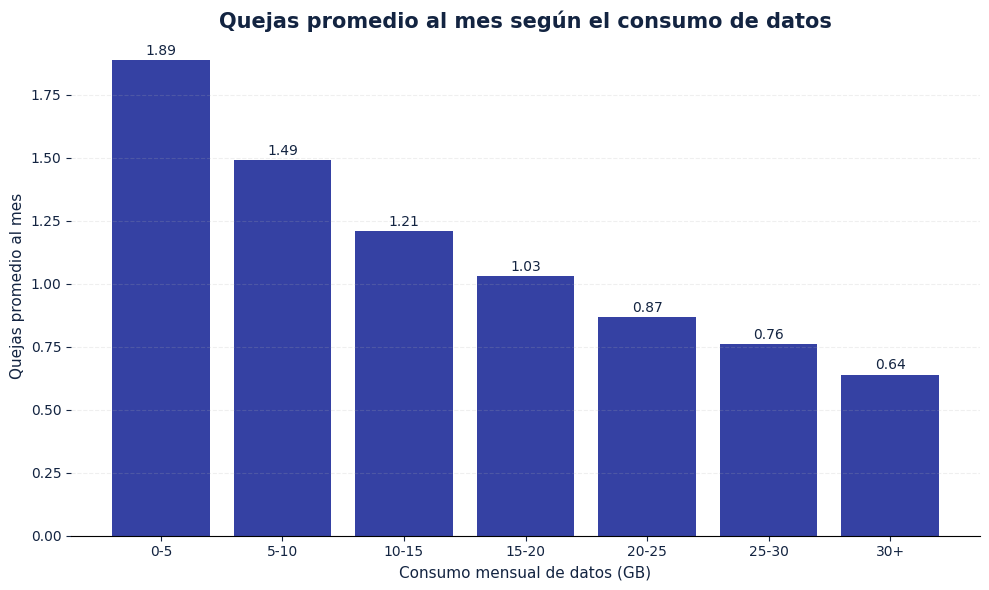

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(
    resumen_consumo.index.astype(str),
    resumen_consumo["quejas_promedio"],
    color="#3541A3",
    edgecolor="none"
)

ax.set_title(
    "Quejas promedio al mes según el consumo de datos",
    fontsize=15,
    fontweight="bold",
    color="#132441"
)

ax.set_xlabel(
    "Consumo mensual de datos (GB)",
    fontsize=11,
    color="#132441"
)

ax.set_ylabel(
    "Quejas promedio al mes",
    fontsize=11,
    color="#132441"
)

ax.tick_params(axis="both", colors="#132441")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

for barra, valor in zip(barras, resumen_consumo["quejas_promedio"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.2f}",
        ha="center",
        fontsize=10,
        color="#132441"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

mes,2026-03,2026-04,2026-05
rango_consumo,,,
0-5,1.76,1.90,2.00
5-10,1.43,1.50,1.55
10-15,1.17,1.22,1.25
15-20,1.00,1.03,1.06
20-25,0.86,0.87,0.90
25-30,0.76,0.75,0.78
30+,0.62,0.65,0.64


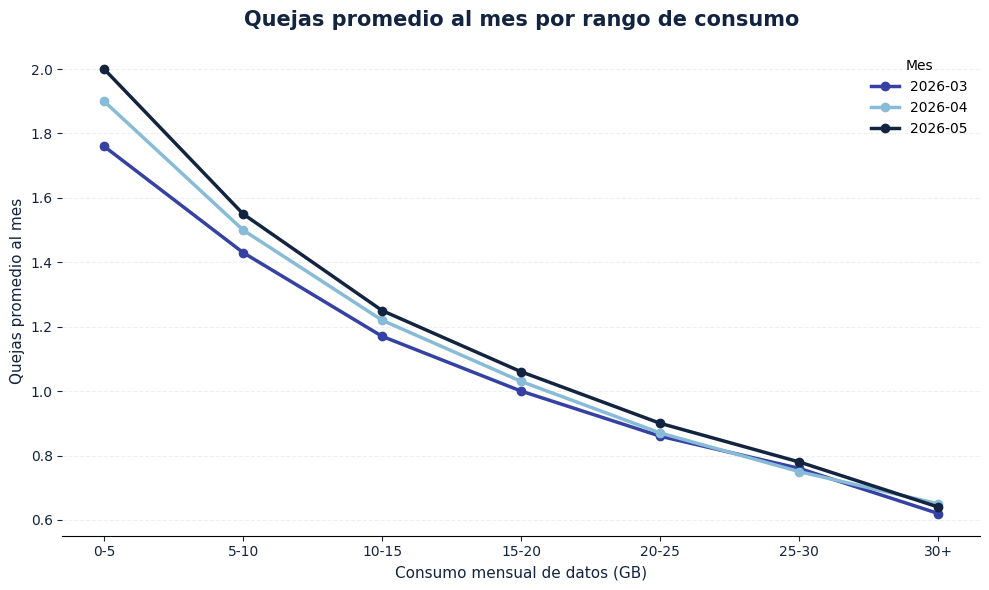

In [ ]:
resumen_mes = df.pivot_table(
    index="rango_consumo",
    columns="mes",
    values="complaints_month",
    aggfunc="mean",
    observed=True,
).round(2)

display(resumen_mes)

fig, ax = plt.subplots(figsize=(10, 6))

colores = ["#3541A3", "#87BBD7", "#132441"]

for mes, color in zip(resumen_mes.columns, colores):
    ax.plot(
        resumen_mes.index.astype(str),
        resumen_mes[mes],
        marker="o",
        linewidth=2.5,
        color=color,
        label=mes
    )

ax.set_title(
    "Quejas promedio al mes por rango de consumo",
    fontsize=15,
    fontweight="bold",
    color="#132441",
    pad=15
)

ax.set_xlabel(
    "Consumo mensual de datos (GB)",
    fontsize=11,
    color="#132441"
)

ax.set_ylabel(
    "Quejas promedio al mes",
    fontsize=11,
    color="#132441"
)

ax.tick_params(axis="both", colors="#132441")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.2
)

ax.legend(
    title="Mes",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
data = df[['complaints_month', 'data_usage_gb']].dropna()

data['complaints_bin'] = pd.cut(
    data['complaints_month'],
    bins=10
)

data['usage_bin'] = pd.cut(
    data['data_usage_gb'],
    bins=10
)

heatmap_data = pd.crosstab(
    data['complaints_bin'],
    data['usage_bin']
)

fig = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=[str(x) for x in heatmap_data.columns],
        y=[str(y) for y in heatmap_data.index],
        
        colorscale=[
            [0, "#EAF4F8"],
            [0.25, "#87BBD7"],
            [0.5, "#5F7BC4"],
            [0.75, "#3541A3"],
            [1, "#132441"]
        ],

        text=heatmap_data.values,
        texttemplate="%{text}",

        hovertemplate=(
            "Consumo de datos: %{x}<br>"
            "Quejas: %{y}<br>"
            "Registros: %{z}<extra></extra>"
        ),

        colorbar=dict(
            title="Registros"
        )
    )
)

fig.update_layout(
    title=dict(
        text="Distribución de clientes según consumo y número de quejas",
        font=dict(
            size=16,
            color="#132441"
        )
    ),

    xaxis_title="Consumo de datos (GB)",
    yaxis_title="Quejas mensuales",

    template="plotly_white",

    font=dict(
        color="#132441"
    )
)

fig.show()

### 5. Conclusiones propias

#### 5.1 Carga y estructura del data set 
#### El dataset contiene 453.803 registros y 20 variables. Estas hacen referencia a características geográficas, comerciales y de comportamiento de los clientes. Los registros corresponden a los meses de Marzo, Abril y Mayo de 2026. El dataset contiene variables numéricas, categóricas, geográficas y temporales. lo que permite realizar diferentes tipos de análisis exploratorio y establecer relaciones entre las características de los clientes, su experiencia con el servicio y su comportamiento de permanencia o abandono.

### 5.2 Calidad de datos
#### *Validacion duplicados:* Se identificaron 1.355 registros completamente duplicados, lo que representa aproximadamente el 0,30 % del total de registros. Aunque este porcentaje es bajo frente al tamaño total del dataset, estos registros pueden afectar los resultados de análisis posteriores al contabilizar más de una vez la misma información. Por esta razón, deben ser revisados durante la etapa de limpieza antes de calcular indicadores sobre clientes, ingresos, quejas o churn. 
#### La combinación de user_id y mes permite evaluar si existe más de un registro para un mismo cliente durante un mismo período. Esta validación es relevante debido a que un cliente puede aparecer legítimamente en diferentes meses, pero no debería asumirse que múltiples registros dentro del mismo mes representan necesariamente clientes diferentes. Los casos identificados mediante esta combinación deberán ser revisados para determinar si corresponden a registros válidos del negocio o a posibles duplicados.

#### *Diferencias en escritura:* Se identificaron inconsistencias en la escritura de algunas variables categóricas. En region se encontraron categorías que representan conceptualmente el mismo valor pero presentan diferencias en tildes, mayúsculas o escritura, mientras que en plan_type se identificaron diferencias principalmente relacionadas con el uso de mayúsculas y minúsculas. Estas inconsistencias pueden fragmentar las categorías y afectar los conteos y comparaciones posteriores. Se sugiere normalización de los datos obtenidos

#### *Validacion longitud y latitud:* La validación identificó 1.362 registros con coordenadas (0,0)  y 4.537 registros fuera del rango geográfico esperado. Estos resultados evidencian inconsistencias en la información geográfica, especialmente en los registros ubicados fuera del área esperada para el análisis, por lo que deberán investigarse antes de realizar análisis geográficos.
 

#### *Conclusión nulos:* Se identificó una alta concentración de valores nulos en churn_date y churn_type, con 440.576 registros (97,09 %) en cada variable, y en nps_score, con 365.347 registros (80,51 %). Por otro lado, latitud y longitud presentan 6.805 valores nulos (1,50 %) cada una. Las demás variables no presentan valores faltantes. Los nulos de las variables relacionadas con churn deberán analizarse según la lógica del negocio, mientras que los de nps_score y las coordenadas deberán considerarse en los análisis que utilicen estas variables.

### 5.3 Estadistica Descriptiva

#### Conclusión: El nps_score no está disponible en todas las filas. Presenta 365.347 valores nulos, equivalentes al 80,51 % del dataset, por lo que existe una alta ausencia de información para esta variable. Al comparar estos valores con churned, se observa que la mayor parte de los registros sin NPS corresponde a usuarios activos (churned = 0), mientras que entre los usuarios que presentaron churn aproximadamente la mitad cuenta con información de NPS. Esto indica que los valores faltantes de nps_score no parecen distribuirse de manera completamente aleatoria y podrían estar relacionados con el estado de churn del usuario.

### 5.4 Visualizaciones

#### *Gráfica Distribución de usuarios por región:* La región Andina concentra 273.614 registros, aproximadamente 3,5 veces más que Caribe (79.269) y 3,8 veces más que Pacífica (72.201). Orinoquia y Amazonia presentan una participación considerablemente menor, con 20.399 y 8.320 registros, respectivamente. Esto evidencia una fuerte concentración geográfica de los registros en la región Andina.

#### *Gráfica Usuarios por tier localidad:* La mayor proporción de usuarios pertenece al nivel Medio, con 40,7 %, seguido por el nivel Alto, con 35,5 %. El nivel Bajo representa el 23,8 % de los usuarios. En conjunto, los niveles Medio y Alto concentran 76,2 % de los usuarios, evidenciando una mayor concentración de clientes en localidades de nivel medio y alto.

#### *Gráfica Evolución mensual de altas y churn:* A partir de abril, las altas superan al churn, con aproximadamente 5.100 altas frente a 4.400 casos de churn en abril y 5.000 frente a 4.600 en mayo. Esto indica un balance positivo de captación durante estos meses, aunque la diferencia entre altas y bajas se reduce ligeramente en mayo.

#### *Gráfica Quejas promedio al mes según el consumo de datos:* El promedio de quejas disminuye de 1,89 a 0,64 a medida que el consumo aumenta de 0–5 GB a más de 30 GB, evidenciando una asociación negativa entre ambas variables. Esto sugiere que los usuarios con menor consumo presentan una mayor frecuencia de quejas; sin embargo, esta relación no implica necesariamente que el consumo sea la causa de las quejas.

#### *Gráfica Quejas promedio al mes por rango de consumo (por mes):* En los tres meses se mantiene una relación inversa entre el consumo de datos y el promedio de quejas: los usuarios de 0–5 GB presentan los mayores promedios, alcanzando 2,00 quejas en mayo, mientras que los usuarios de 30 GB o más presentan los menores valores, alrededor de 0,62–0,65 quejas. Además, mayo registra los mayores promedios de quejas en casi todos los rangos de consumo. Esto sugiere que los usuarios de menor consumo concentran una mayor frecuencia de quejas y que este comportamiento se mantiene durante los tres meses analizados.

#### *Gráfica Heatmap: Monthly Complaints vs Data Usage:* El mapa muestra una concentración de usuarios en los niveles bajos de quejas, especialmente entre 0 y 1,8 quejas mensuales, donde se encuentra el mayor número de registros. La combinación más frecuente presenta 116.019 registros, correspondiente a un consumo entre 6,09 y 12,08 GB. Las frecuencias disminuyen notablemente al aumentar el número de quejas y el consumo.

### 6. Comparación con housing

#### Similitudes con California Housing
*Valores nulos:* Ambos datasets presentan datos faltantes. En CONECTA hay 1,50 % de nulos en latitud y longitud, mientras que en California Housing existen aproximadamente 207 nulos en total_bedrooms.
Valores atípicos o anomalías: CONECTA presenta 4.537 coordenadas fuera del rango esperado de Colombia y 1.362 registros con (0,0). En California Housing, median_house_value presenta un tope de $500.001, que afecta la distribución de los datos.
Distribuciones desbalanceadas: Ambos datasets presentan distribuciones que requieren atención antes de modelar. En CONECTA destaca el desbalance relacionado con churn, mientras que en Housing existen sesgos en variables como median_income.


#### Lo nuevo en CONECTA
*Estructura de panel:* Un mismo user_id aparece en diferentes meses, permitiendo analizar la evolución del cliente y el churn a través del tiempo.
Variantes de texto: region y plan_type presentan diferencias de mayúsculas, tildes y espacios que deben estandarizarse.
Nulos estructurales: Algunos nulos tienen significado de negocio. Por ejemplo, el 97,09 % de nulos en churn_date puede indicar que el cliente continúa activo, mientras que el 80,51 % de nulos en nps_score puede estar relacionado con la ausencia de respuesta a la encuesta.
Jerarquía geográfica: CONECTA maneja una estructura relacionada entre país → región → ciudad → localidad, que requiere validar la consistencia entre niveles.
Duplicados: Se identificaron 1.355 registros completamente duplicados (0,30 %), un problema especialmente relevante al trabajar con datos mensuales de clientes.